# Phase 1 (Part 2): Data Cleaning & Visualizations
In the real world, GPS data is noisy. Sometimes the signal bounces, creating negative travel times, or the bus breaks down, creating a 3-hour travel time for a 500-meter segment. Let's find and remove these outliers.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

# Load datasets
data_dir = '../data/raw/archive/'
running_times_df = pd.read_csv(data_dir + 'bus_running_times_654.csv')
dwell_times_df = pd.read_csv(data_dir + 'bus_dwell_times_654.csv')

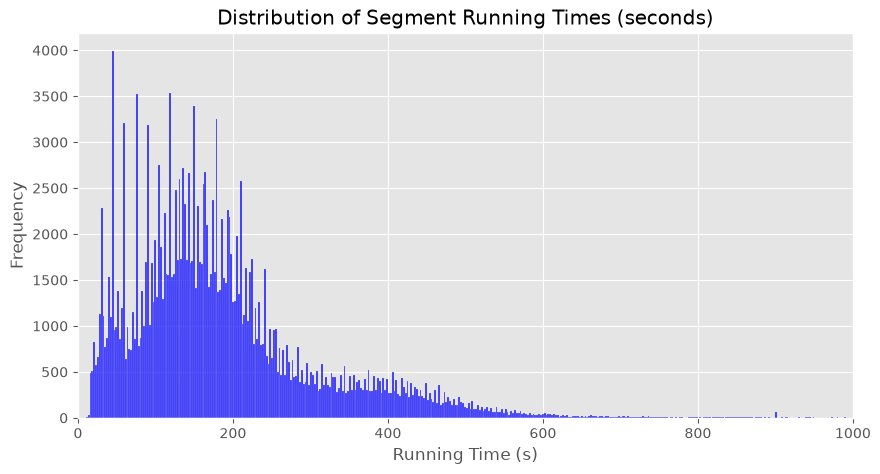

In [4]:
# 1. Plot the distribution of Segment Running Times
plt.figure(figsize=(10, 5))
# We limit the x-axis to 1000 seconds just to see the main distribution clearly
sns.histplot(running_times_df['run_time_in_seconds'], bins=500, kde=False, color='blue')
plt.title('Distribution of Segment Running Times (seconds)')
plt.xlabel('Running Time (s)')
plt.ylabel('Frequency')
plt.xlim(0, 1000)
plt.show()

In [5]:
# 2. Find the anomalies (Outliers)
negative_times = len(running_times_df[running_times_df['run_time_in_seconds'] <= 0])
extreme_times = len(running_times_df[running_times_df['run_time_in_seconds'] > 1800]) # > 30 minutes for one segment

print(f"Number of impossible (<= 0s) run times: {negative_times}")
print(f"Number of extreme outliers (> 30 mins): {extreme_times}")

Number of impossible (<= 0s) run times: 0
Number of extreme outliers (> 30 mins): 0


In [6]:
# 3. Clean the dataset
clean_running_times = running_times_df[(running_times_df['run_time_in_seconds'] > 0) & (running_times_df['run_time_in_seconds'] <= 1800)].copy()
retention_rate = (len(clean_running_times) / len(running_times_df)) * 100

print(f"Data cleaned! We retained {retention_rate:.2f}% of the original dataset.")

Data cleaned! We retained 98.79% of the original dataset.
